In [ ]:
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.metrics import roc_curve, auc

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.covariance import MinCovDet
from scipy.spatial.distance import mahalanobis

## Import/ Xử lý


In [ ]:
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Colab Notebooks/Dataset/PimaDiabetes/diabetes.csv'
df = pd.read_csv(path)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']

# Đếm số giá trị 0 trong mỗi cột
zero_counts = (df[cols] == 0).sum()
print(zero_counts)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [ ]:
cols_zero_invalid = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

# Thay 0 bằng median theo lớp Outcome
for col in cols_zero_invalid:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))

In [4]:
# Chuẩn hóa Pregnancies về binary trên df_clean
df['Pregnancies'] = (df['Pregnancies'] >= 1).astype(int)

In [ ]:
features = df.drop('Outcome', axis=1).columns

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

df_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1.0,0.670968,0.489796,0.304348,0.186899,0.314928,0.234415,0.483333,1
1,1.0,0.264516,0.428571,0.239130,0.106370,0.171779,0.116567,0.166667,0
2,1.0,0.896774,0.408163,0.271739,0.186899,0.104294,0.253629,0.183333,1
3,1.0,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000,0
4,0.0,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000,1


# Phân cụm


In [ ]:
# Danh sách biến cần kiểm tra outlier
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

# Ngưỡng riêng từng biến, chỉnh số trực tiếp ở đây
threshold_factors = {
    'Pregnancies': 0,
    'Glucose': 1.29,
    'BloodPressure': 1.75,
    'SkinThickness': 1.75,
    'Insulin': 1.75,
    'BMI': 1.75,
    'DiabetesPedigreeFunction': 1.75,
    'Age': 1.75   # muốn chỉnh thì sửa số này thôi
}

df_clean_list = []
df_outlier_list = []

# Lặp qua từng nhãn
for label in df_scaled['Outcome'].unique():
    df_label = df_scaled[df_scaled['Outcome'] == label].copy()
    X_label = df_label[features].values

    # DataFrame đánh dấu outlier cho từng biến
    outlier_flags = pd.DataFrame(False, index=df_label.index, columns=features)

    for i, col in enumerate(features):
        # KMeans 1D để tìm centroid của biến
        kmeans = KMeans(n_clusters=1, random_state=42).fit(X_label[:, [i]])
        centroid = kmeans.cluster_centers_[0][0]

        # Khoảng cách tuyệt đối tới centroid
        distances = np.abs(X_label[:, i] - centroid)

        # Ngưỡng riêng theo biến (chỉnh ở threshold_factors)
        factor = threshold_factors[col]
        threshold = np.mean(distances) + factor * np.std(distances)

        # Gắn cờ nếu vượt ngưỡng
        outlier_flags[col] = distances > threshold

    # Một dòng là outlier nếu ít nhất một biến bị đánh dấu
    is_outlier = outlier_flags.any(axis=1)

    # Phân tách dữ liệu sạch và dữ liệu nhiễu
    df_clean_list.append(df_label[~is_outlier])
    df_outlier_list.append(df_label[is_outlier])

# Ghép dữ liệu sạch và nhiễu từ các lớp
df_clean = pd.concat(df_clean_list).reset_index(drop=True)
df_outlier = pd.concat(df_outlier_list).reset_index(drop=True)

# Kiểm tra số lượng dữ liệu
print("Số lượng dữ liệu sạch:", len(df_clean))
print("Số lượng dữ liệu nhiễu:", len(df_outlier))

Số lượng dữ liệu sạch: 446
Số lượng dữ liệu nhiễu: 322


# Cohen D


In [7]:
def cohens_d(df, feature, label='Outcome'):
    group0 = df[df[label]==0][feature]
    group1 = df[df[label]==1][feature]
    n0, n1 = len(group0), len(group1)
    s0, s1 = np.var(group0, ddof=1), np.var(group1, ddof=1)
    s_pooled = np.sqrt(((n0-1)*s0 + (n1-1)*s1)/(n0+n1-2))
    d = (group1.mean() - group0.mean()) / s_pooled
    return d

# Chọn các feature cần đánh giá
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']

# Tính Cohen's d
cohen_values = [cohens_d(df_clean, f) for f in features]

# Tạo DataFrame để plot
df_cohen = pd.DataFrame({'Feature': features, 'Cohens_d': cohen_values})
df_cohen = df_cohen.sort_values(by='Cohens_d', ascending=False)  # sắp xếp để dễ nhìn
df_cohen


/tmp/ipython-input-1942313913.py:7: RuntimeWarning: invalid value encountered in scalar divide
  d = (group1.mean() - group0.mean()) / s_pooled


,Feature,Cohens_d
4,Insulin,1.696275
1,Glucose,1.658717
7,Age,1.019939
3,SkinThickness,0.929754
5,BMI,0.781987
6,DiabetesPedigreeFunction,0.578943
2,BloodPressure,0.535747
0,Pregnancies,NaN


/tmp/ipython-input-1612178873.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cohens_d', y='Feature', data=df_cohen, palette='viridis')


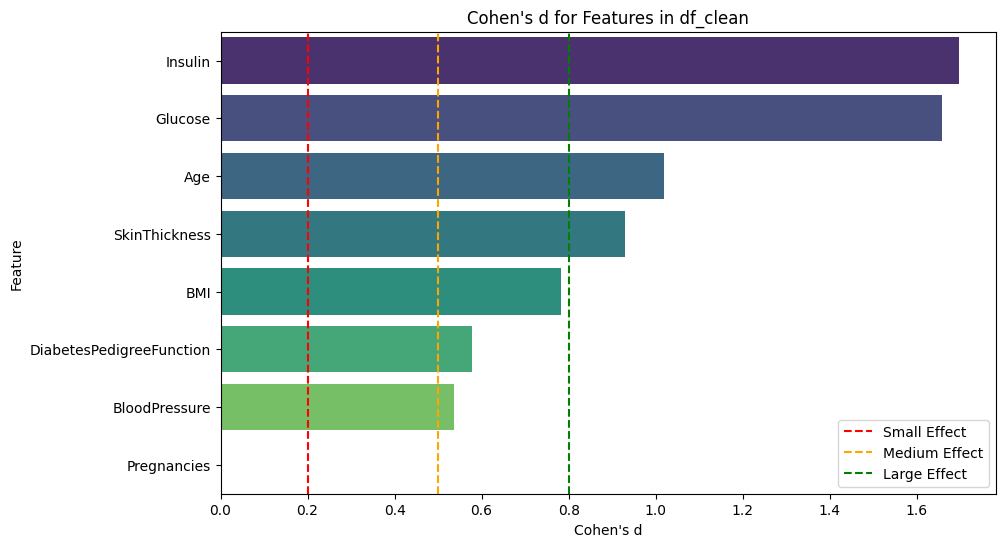

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Cohens_d', y='Feature', data=df_cohen, palette='viridis')
plt.axvline(x=0.2, color='red', linestyle='--', label='Small Effect')
plt.axvline(x=0.5, color='orange', linestyle='--', label='Medium Effect')
plt.axvline(x=0.8, color='green', linestyle='--', label='Large Effect')
plt.title("Cohen's d for Features in df_clean")
plt.xlabel("Cohen's d")
plt.ylabel("Feature")
plt.legend()
plt.show()

# SCGClassifier


# Chuẩn bị dữ liệu/import


In [10]:
# Giả sử df_clean đã có sẵn
X = df_clean.drop(columns=['Outcome'])  # thay 'Outcome' nếu cột nhãn khác
y = df_clean['Outcome']

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Huấn luyện mô hình SGDClassifier


In [12]:
param_grid = {
    'loss': ['modified_huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [1e-5, 1e-4, 1e-3],
    'learning_rate': ['optimal', 'adaptive'],
    'eta0': [0.001, 0.01, 0.1],
    'class_weight': [None, 'balanced']
}

sgd = SGDClassifier(max_iter=1000, random_state=42)

grid = GridSearchCV(
    sgd, param_grid,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)

grid.fit(X_train_scaled, y_train)

# Lấy mô hình tốt nhất
best_sgd = grid.best_estimator_

print("Best Params:", grid.best_params_)
print("Best AUC (CV):", grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Params: {'alpha': 0.001, 'class_weight': 'balanced', 'eta0': 0.01, 'learning_rate': 'adaptive', 'loss': 'modified_huber', 'penalty': 'l1'}
Best AUC (CV): 0.9464273820536541


In [13]:
print("Best Params:", grid.best_params_)

Best Params: {'alpha': 0.001, 'class_weight': 'balanced', 'eta0': 0.01, 'learning_rate': 'adaptive', 'loss': 'modified_huber', 'penalty': 'l1'}


# Dự đoán & đánh giá


In [14]:
# Dự đoán
y_pred = best_sgd.predict(X_test_scaled)
y_proba = best_sgd.predict_proba(X_test_scaled)[:, 1]

# Đánh giá
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}\n")
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)
print(f"AUC: {auc:.4f}")


Accuracy: 0.9111
F1-score: 0.8788

Confusion Matrix:
 [[53  5]
 [ 3 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93        58
           1       0.85      0.91      0.88        32

    accuracy                           0.91        90
   macro avg       0.90      0.91      0.90        90
weighted avg       0.91      0.91      0.91        90

AUC: 0.9725


# Phân bố


/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


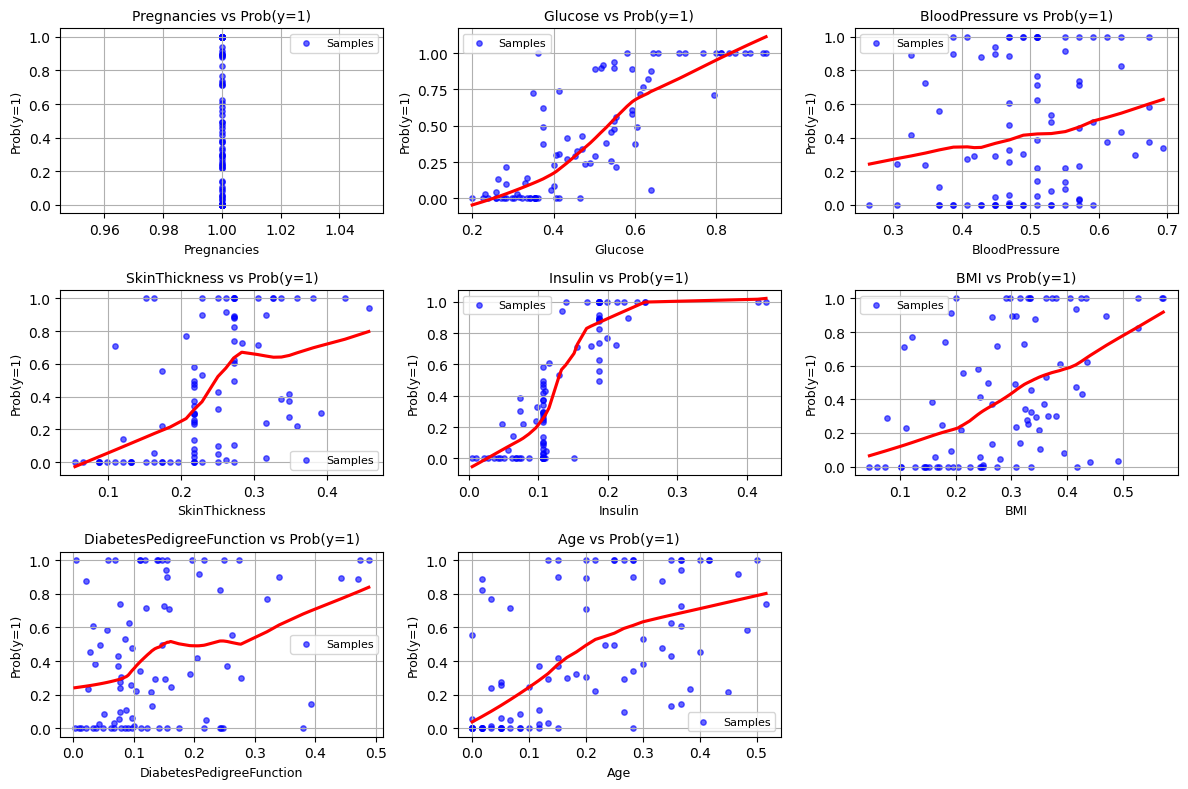

In [15]:
features = X_test.columns  # giữ nguyên tất cả biến
y_proba = best_sgd.predict_proba(X_test_scaled)[:,1]

plt.figure(figsize=(12,8))  # figure nhỏ gọn

for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)  # bố cục 3x3
    # Scatter plot các điểm dữ liệu
    plt.scatter(X_test[feature], y_proba, s=15, alpha=0.6, color='blue', label='Samples')

    # Vẽ đường trend mượt (lowess)
    sns.regplot(x=X_test[feature], y=y_proba, lowess=True, scatter=False, color='red', line_kws={'label':'Trend'})

    plt.xlabel(feature, fontsize=9)
    plt.ylabel('Prob(y=1)', fontsize=9)
    plt.title(f'{feature} vs Prob(y=1)', fontsize=10)
    plt.legend(fontsize=8)
    plt.grid(True)

plt.tight_layout()
plt.show()


# Vẽ biểu đồ ROC & Precision-Recall


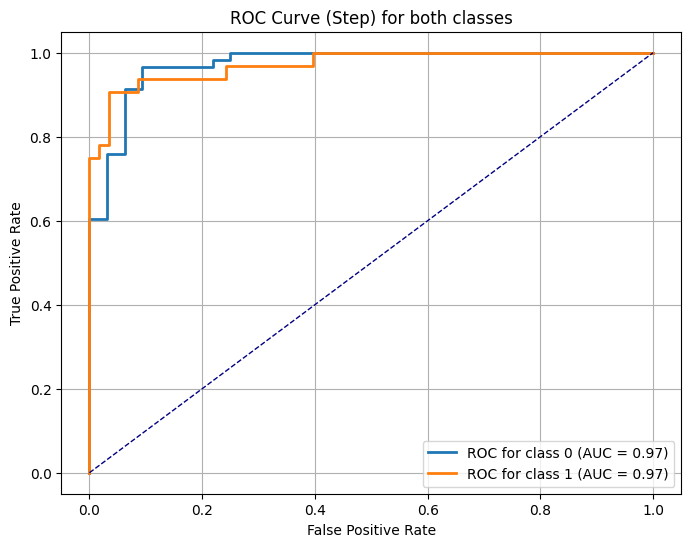

In [ ]:
# Xác suất nhãn 1
y_proba = best_sgd.predict_proba(X_test_scaled)

plt.figure(figsize=(8,6))

for i, label in enumerate([0,1]):
    fpr, tpr, _ = roc_curve(y_test, y_proba[:, i], pos_label=i)
    roc_auc = auc(fpr, tpr)

    # Vẽ đường gấp khúc
    plt.step(fpr, tpr, where='post', lw=2, label=f'ROC for class {label} (AUC = {roc_auc:.2f})')

# Đường chéo ngẫu nhiên
plt.plot([0,1], [0,1], color='navy', lw=1, linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Step) for both classes')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

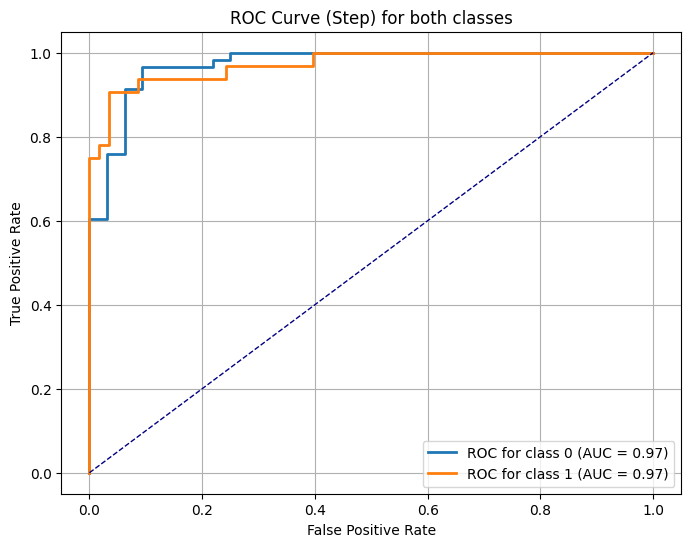

In [ ]:
# Tạo figure mà không gọi plt.show()
fig, ax = plt.subplots(figsize=(8,6))

y_proba = best_sgd.predict_proba(X_test_scaled)

for i, label in enumerate([0,1]):
    fpr, tpr, _ = roc_curve(y_test, y_proba[:, i], pos_label=i)
    roc_auc = auc(fpr, tpr)
    ax.step(fpr, tpr, where='post', lw=2, label=f'ROC for class {label} (AUC = {roc_auc:.2f})')

ax.plot([0,1], [0,1], color='navy', lw=1, linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (Step) for both classes')
ax.legend(loc='lower right')
ax.grid(True)

# Lưu figure vào biến tạm
roc_figure = fig

# Nếu muốn hiển thị sau này:
# roc_figure.show()


# Random Forest


In [18]:
print(df_outlier['Outcome'].value_counts())

Outcome
0    211
1    111
Name: count, dtype: int64


In [ ]:
# X, y
X = df_clean.drop(columns=['Outcome']).values
y = df_clean['Outcome'].values

# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Cân bằng dữ liệu bằng SMOTE
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_scaled, y)

# Robust covariance estimate
robust_cov = MinCovDet().fit(X_bal)
cov_inv = np.linalg.pinv(robust_cov.covariance_)

# Hàm khoảng cách Mahalanobis robust
def robust_mahalanobis(u, v):
    return mahalanobis(u, v, cov_inv)

# Tách train/test
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.3, random_state=42)

# KNN robust
knn = KNeighborsClassifier(n_neighbors=5, metric=robust_mahalanobis)
knn.fit(X_train, y_train)

# Dự đoán
y_pred = knn.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
y_proba = knn.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_proba)

# In kết quả
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}\n")
print("Confusion Matrix:\n", cm, "\n")
print("Classification Report:\n", report)
print(f"AUC: {auc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


Accuracy: 0.8736
F1-score: 0.8735

Confusion Matrix:
 [[74 12]
 [10 78]] 

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87        86
           1       0.87      0.89      0.88        88

    accuracy                           0.87       174
   macro avg       0.87      0.87      0.87       174
weighted avg       0.87      0.87      0.87       174

AUC: 0.9430


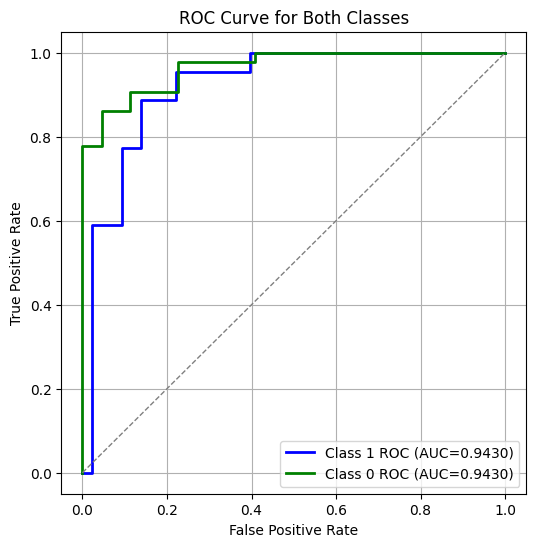

In [ ]:
# Giả sử y_test và y_proba đã có từ mô hình KNN
# y_proba = knn.predict_proba(X_test)[:,1]

# ROC lớp 1
fpr1, tpr1, _ = roc_curve(y_test, y_proba)
auc1 = auc(fpr1, tpr1)

# ROC lớp 0
fpr0, tpr0 = 1 - tpr1, 1 - fpr1
auc0 = auc(fpr0, tpr0)

# Vẽ figure
fig, ax = plt.subplots(figsize=(6,6))

ax.plot(fpr1, tpr1, color='blue', lw=2,
        label=f'Class 1 ROC (AUC={auc1:.4f})', drawstyle='steps-post')
ax.plot(fpr0, tpr0, color='green', lw=2,
        label=f'Class 0 ROC (AUC={auc0:.4f})', drawstyle='steps-post')
ax.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve for Both Classes')
ax.legend(loc='lower right')
ax.grid(True)

# Lưu figure vào biến tạm
roc_figure_2 = fig

# Hiển thị
plt.show()

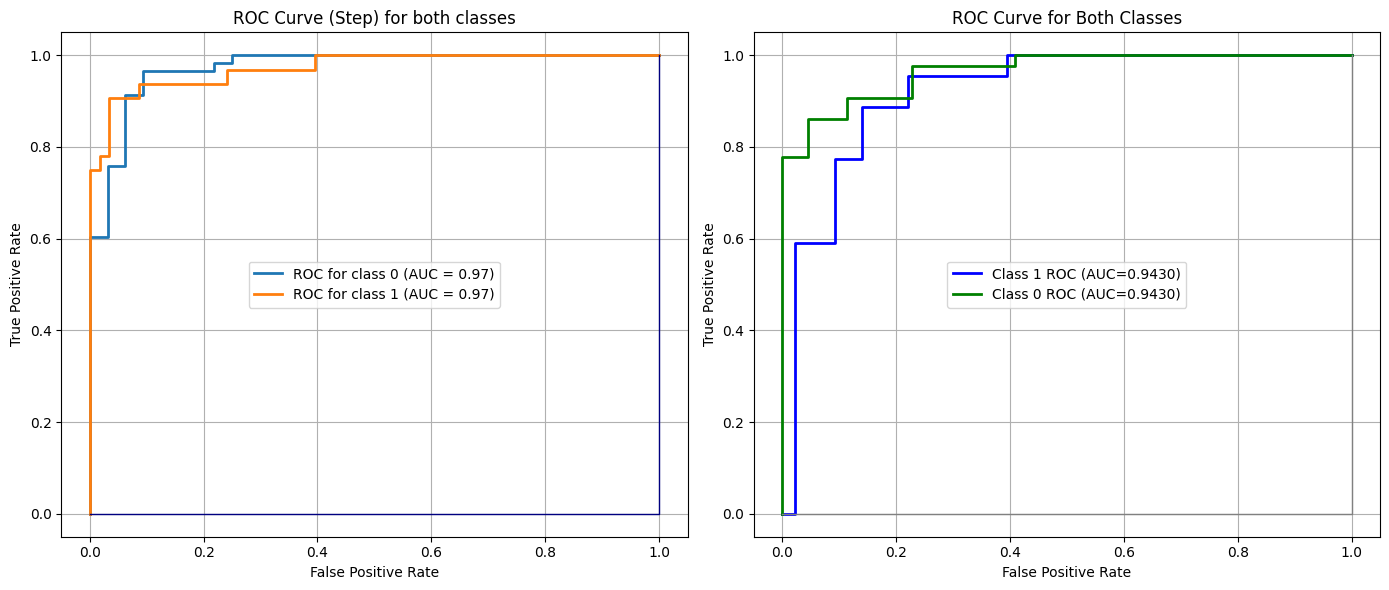

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ----- Bên trái: roc_figure -----
for ax_old in roc_figure.axes:  # lặp qua tất cả axes cũ
    for line in ax_old.get_lines():
        axes[0].plot(line.get_xdata(), line.get_ydata(),
                     color=line.get_color(),
                     lw=line.get_linewidth(),
                     label=line.get_label(),
                     drawstyle='steps-post')  # giữ dạng bậc thang
axes[0].set_title(roc_figure.axes[0].get_title())
axes[0].set_xlabel(roc_figure.axes[0].get_xlabel())
axes[0].set_ylabel(roc_figure.axes[0].get_ylabel())
axes[0].legend()
axes[0].grid(True)

# ----- Bên phải: roc_figure_2 -----
for ax_old in roc_figure_2.axes:
    for line in ax_old.get_lines():
        axes[1].plot(line.get_xdata(), line.get_ydata(),
                     color=line.get_color(),
                     lw=line.get_linewidth(),
                     label=line.get_label(),
                     drawstyle='steps-post')  # giữ dạng bậc thang
axes[1].set_title(roc_figure_2.axes[0].get_title())
axes[1].set_xlabel(roc_figure_2.axes[0].get_xlabel())
axes[1].set_ylabel(roc_figure_2.axes[0].get_ylabel())
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
